In [51]:
import pandas as pd
# Librerías para datos y gráficos
import numpy as np          # Para trabajar con arreglos numéricos
import pandas as pd         # Para manejar tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Para hacer gráficos

# Para manejar fechas y el sistema operativo
import datetime             # Para trabajar con fechas y horas
import os                   # Para funciones de archivos y carpetas

# Herramientas de machine learning (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV  # Dividir datos, validación y búsqueda de parámetros
from sklearn.preprocessing import StandardScaler                                  # Escalar datos
from sklearn.pipeline import Pipeline                                            # Encadenar pasos de datos y modelos
from sklearn.metrics import roc_auc_score, roc_curve, auc                       # Medir calidad de los modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Modelos de árboles
from sklearn.linear_model import LogisticRegression                             # Modelo de regresión

# Para análisis de supervivencia
from lifelines import KaplanMeierFitter                                       # Para crear curvas de supervivencia
from lifelines.statistics import logrank_test                                 # Prueba para comparar curvas
from sksurv.ensemble import RandomSurvivalForest                              # Modelo de bosque para supervivencia
from sksurv.util import Surv                                                   # Formato de datos para supervivencia
from sksurv.metrics import concordance_index_censored                        # Medida para evaluar modelos de supervivencia

# Para redes neuronales con TensorFlow/Keras
import tensorflow as tf                                                        # Framework de deep learning
from tensorflow.keras.models import Sequential                               # Modelo básico en capas
from tensorflow.keras.layers import Dense, Dropout                          # Capas para red neuronal
from tensorflow.keras.optimizers import Adam                                # Algoritmo para entrenar la red
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard          # Para controlar y monitorear el entrenamiento

# Para balancear datos y generar muestras nuevas
from imblearn.over_sampling import SMOTE                                   # Para balancear datos desbalanceados
from ctgan import CTGAN                                                    # Para crear datos sintéticos

# Para usar XGBoost, un modelo potente basado en árboles
import xgboost as xgb          

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [52]:
top25_genes = [
    "CD74",
    "HLA-DPB1",
    "HLA-DRB1",
    "HLA-DMA",
    "HLA-DMB",
    "HLA-DRA",
    "HLA-DPA1",
    "HLA-DOA",
    "HLA-E",
    "HLA-DQA1",
    "PTPRC",
    "LYN",
    "IL10",
    "CD3E",
    "FCGR3A",
    "LCK",
    "CASP1",
    "CD2",
    "B2M",
    "LCP2",
    "SERPING1",
    "CD4",
    "FCER1G",
    "C1QB",
    "C1QC"
]

In [53]:
path_rppa = '../data/Human__TCGA_LGG__MDA__RPPA__MDA_RPPA__01_28_2016__BI__Gene__Firehose_RPPA.cct.txt'
path_mutation = '../data/Human__TCGA_LGG__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt.txt'

path_scna_gen = '../data/Human__TCGA_LGG__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct'

rppa = pd.read_csv(path_rppa, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)
scna_gen = pd.read_csv(path_scna_gen, sep='\t', index_col=0)

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (148, 429)
Dimensión datos mutaciones: (889, 513)
Dimensión datos scna: (24776, 513)


In [54]:
rppa = rppa.loc[rppa.index.isin(top25_genes)]
scna_gen = scna_gen.loc[scna_gen.index.isin(top25_genes)]
muta = muta.loc[muta.index.isin(top25_genes)]

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

'''
Parametros optimizados para cada cual
top25_genes, se queda con 16:
top=['C1QC', 'C1QB', 'LCK', 'CD2', 'FCER1G', 'FCGR3A', 'PTPRC', 'IL10', 'CD74', 'LCP2', 'LYN', 'SERPING1', 'CASP1', 'CD3E', 'CD4', 'B2M']
Random Forest 0.879
XGBoost 0.843
Gradient Boosting 0.884

top_genes, se queda con 86:
top=['ISG15', 'C1QC', 'C1QB', 'RUNX3', 'LAPTM5', 'LCK', 'IFI44L', 'CD53', 'PTPN22', 'CD2', 'CTSS', 'FCER1G', 'FCGR2B', 'FCGR3A', 'PTPRC', 'IL10', 'RSAD2', 'IFIH1', 'CASP8', 'CCR1', 'CCR2', 'CCR5', 'CD80', 'CD86', 'HERC5', 'DAPP1', 'TIFA', 'ALPK1', 'TLR3', 'IL7R', 'GZMK', 'GZMA', 'CD74', 'HAVCR2', 'ITK', 'LCP2', 'C2', 'NCF1', 'COL1A2', 'LYN', 'SYK', 'PTGS1', 'ALOX5', 'PRF1', 'CD44', 'SPI1', 'SERPING1', 'CASP4', 'CASP1', 'CD3E', 'CD3D', 'CD4', 'PTPN6', 'C1S', 'CD163', 'CLEC7A', 'ITGB7', 'ITGA5', 'ANG', 'RNASE2', 'MMP14', 'RIPK3', 'GZMH', 'PYGL', 'B2M', 'PLCG2', 'CYBA', 'PIK3R6', 'PIK3R5', 'CCL5', 'ITGB3', 'COL1A1', 'VAV1', 'ICAM1', 'HCST', 'TYROBP', 'LILRB2', 'HCK', 'RUNX1', 'ITGB2', 'IL2RB', 'TLR7', 'MAOB', 'TIMP1', 'CXCR3', 'BTK']
Random Forest 0.822
XGBoost 0.826
Gradient Boosting 0.801
'''

print(scna_gen.index.tolist())

Dimensión datos rppa: (1, 429)
Dimensión datos mutaciones: (1, 513)
Dimensión datos scna: (16, 513)
['C1QC', 'C1QB', 'LCK', 'CD2', 'FCER1G', 'FCGR3A', 'PTPRC', 'IL10', 'CD74', 'LCP2', 'LYN', 'SERPING1', 'CASP1', 'CD3E', 'CD4', 'B2M']


In [55]:
scna_gen = scna_gen.T 
scna_gen.head()

attrib_name,C1QC,C1QB,LCK,CD2,FCER1G,FCGR3A,PTPRC,IL10,CD74,LCP2,LYN,SERPING1,CASP1,CD3E,CD4,B2M
TCGA.CS.4938,0.004,0.004,0.004,0.003,0.003,0.003,0.003,0.003,-0.002,-0.002,-0.003,-0.001,-0.001,-0.001,0.067,0.007
TCGA.CS.4941,0.459,0.459,0.459,0.447,0.447,0.447,0.444,0.444,0.003,0.003,-0.015,-0.018,-0.014,-0.014,0.004,-0.027
TCGA.CS.4942,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,-0.019,-0.019,0.000,0.001,0.004,0.004,0.017,0.004
TCGA.CS.4943,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,0.005,0.005,-0.007,0.016,0.001,0.001,1.628,0.056
TCGA.CS.4944,-0.009,-0.009,-0.009,-0.691,0.000,0.000,0.000,0.000,0.008,0.008,-0.002,-0.005,0.004,0.004,0.005,-0.011


In [56]:
#data_cox = pd.read_csv('../data/data_cox_with_survival3yr.csv', index_col=0)
data_cox = pd.read_csv('../data/data_cox_with_survival3yr_ht.csv', index_col=0)
data_cox.head()


,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.4117,3.8538,9.7537,234.0,True,-2.580570,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1,1.0,0.0,0.0


In [57]:
import pandas as pd

# Renombrar columnas de scna_gen para indicar origen "_scna"
scna_renamed = scna_gen.add_suffix('_scna')

# Renombrar columnas de data_cox para indicar origen "_expression"
cox_renamed = data_cox.add_suffix('_expression')

# Mantener la columna survival_3yr sin sufijo, directamente desde data_cox
survival_col = data_cox['survival_3yr']

# Encontrar genes comunes basados en nombres base sin sufijo
genes_cox = set([col.replace('_expression', '') for col in cox_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
common_genes = genes_cox.intersection(genes_scna)

# Columnas para filtrar
cols_cox_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]

# Filtrado de columnas para genes comunes
cox_filtered = cox_renamed[cols_cox_common]
scna_filtered = scna_renamed[cols_scna_common]

# Unir los datos por índice (muestras)
merged_data = pd.merge(cox_filtered, scna_filtered, left_index=True, right_index=True, how='inner')

# Añadir la columna survival_3yr de data_cox (sin sufijo)
merged_data = merged_data.join(survival_col, how='inner')

# Ordenar columnas para que cada gen tenga expresión y SCNA lado a lado
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols.append(gene + '_expression')
    ordered_cols.append(gene + '_scna')
ordered_cols.append('survival_3yr')

merged_data = merged_data[ordered_cols]

merged_data.head()


,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LCK_scna,LCP2_expression,LCP2_scna,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,0.004,7.6154,-0.002,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,0.459,9.0451,0.003,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,0.002,9.2850,-0.019,10.4678,0.000,10.3002,0.002,9.8687,0.001,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,-0.043,7.9089,0.005,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,-0.009,6.9549,0.008,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1


In [58]:
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.4117,3.8538,9.7537,234.0,True,-2.580570,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1,1.0,0.0,0.0


In [59]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LCK_scna,LCP2_expression,LCP2_scna,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,0.004,7.6154,-0.002,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,0.459,9.0451,0.003,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,0.002,9.2850,-0.019,10.4678,0.000,10.3002,0.002,9.8687,0.001,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,-0.043,7.9089,0.005,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,-0.009,6.9549,0.008,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1


In [60]:
# Selecciona las columnas histológicas codificadas
hist_cols = [col for col in data_cox.columns if col.startswith('histological_type')]

# Une las columnas histológicas a merged_data (por índice)
merged_data = merged_data.join(data_cox[hist_cols], how='inner')

In [61]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1,1.0,0.0,0.0
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0,1.0,0.0,0.0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,10.4678,0.000,10.3002,0.002,9.8687,0.001,1,1.0,0.0,0.0
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1,1.0,0.0,0.0
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1,1.0,0.0,0.0


In [62]:
# Función para evaluar modelo y obtener AUC
def evaluar_modelo(modelo, X, y, cv):
    auc_scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_scores.append(auc)

    return auc_scores, y_test, y_proba

In [63]:
from imblearn.over_sampling import SMOTE


X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X = X_resampled.values
y = y_resampled.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

[LightGBM] [Info] Number of positive: 257, number of negative: 258
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4759
[LightGBM] [Info] Number of data points in the train set: 515, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499029 -> initscore=-0.003884
[LightGBM] [Info] Start training from score -0.003884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 258, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4793
[LightGBM] [Info] Number of data points in the train set: 515, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500971 -> initscore=0.003884
[LightGBM] [Info] Start training from score 0.003884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


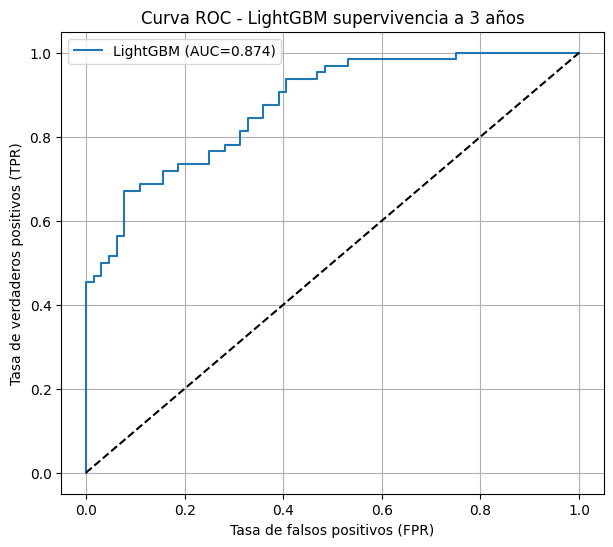

In [64]:
lgbm_clf = LGBMClassifier(random_state=42, colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, num_leaves=31, subsample=0.8)

# Evaluar LightGBM
auc_lgbm, y_test_lgbm, y_proba_lgbm = evaluar_modelo(lgbm_clf, X, y, cv)
print(f"AUC ROC promedio LightGBM (default): {np.mean(auc_lgbm):.4f} ± {np.std(auc_lgbm):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_lgbm, y_proba_lgbm)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC={auc_lgbm[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - LightGBM supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC promedio Random Forest para supervivencia a 3 años: 0.8681 ± 0.0184


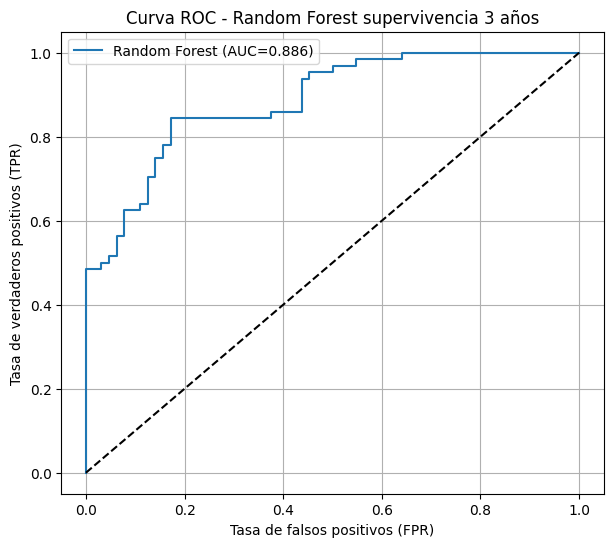

In [65]:
# Definir Random Forest con parámetros ajustados
# 86 caracteristicas
#rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=8, bootstrap=True)

#32 caract
rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=1, max_features=0.3, max_depth=None, bootstrap=False)

# Validación cruzada estratificada 5 pliegues
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluacion
auc_scores, y_test, y_proba = evaluar_modelo(rf, X, y, cv)
print(f"AUC ROC promedio Random Forest para supervivencia a 3 años: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# Grafica ROC para primer fold
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc_scores[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC promedio XGBoost: 0.8374 ± 0.0119


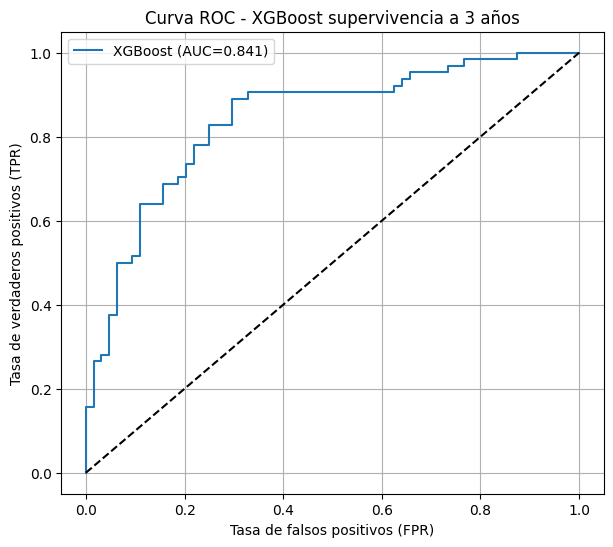

In [66]:
# Definir modelo XGBoost
#86 caract
"""xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.2,
    subsample=0.6,
    colsample_bytree=1.0,
    gamma=0.1,
    random_state=42
)"""

#32 caract
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.6,
    gamma=0,
    random_state=42
)

# Evaluar XGBoost
auc_xgb, y_test_xgb, y_proba_xgb = evaluar_modelo(xgb_clf, X, y, cv)
print(f"AUC ROC promedio XGBoost: {np.mean(auc_xgb):.4f} ± {np.std(auc_xgb):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_xgb, y_proba_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc_xgb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()


AUC ROC promedio Gradient Boosting: 0.8735 ± 0.0220


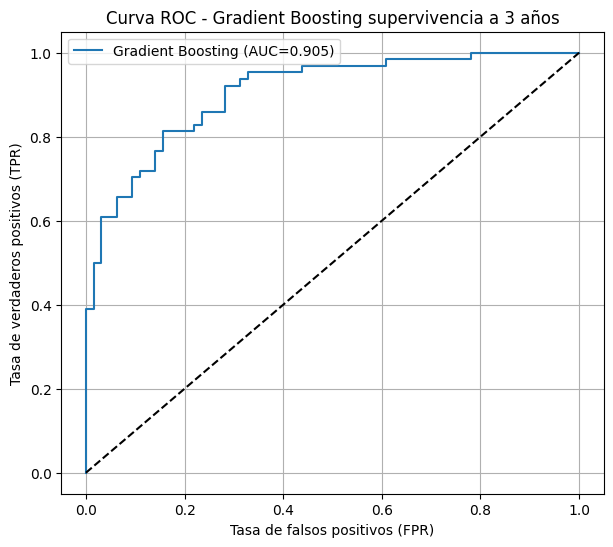

In [73]:
# Definir modelo Gradient Boosting
#86 caract
"""gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    random_state=42,
    max_features= 'log2',
    min_samples_leaf=2,
    min_samples_split=5
)"""

gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    random_state=42,
    max_features= 'sqrt',
    min_samples_leaf=2,
    min_samples_split=5
)

# Evaluar Gradient Boosting
auc_gb, y_test_gb, y_proba_gb = evaluar_modelo(gb_clf, X, y, cv)
print(f"AUC ROC promedio Gradient Boosting: {np.mean(auc_gb):.4f} ± {np.std(auc_gb):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_gb, y_proba_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC={auc_gb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

## Optimizando hiperparametros

[LightGBM] [Info] Number of positive: 322, number of negative: 322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 644, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 257, number of negative: 258
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001877 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4875
[LightGBM] [Info] Number of data points in the train set: 515, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499029 -> initscore=-0.003884
[LightGBM] [Info] Start training from score -0.003884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 258, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4793
[LightGBM] [Info] Number of data points in the train set: 515, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500971 -> initscore=0.003884
[LightGBM] [Info] Start training from score 0.003884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


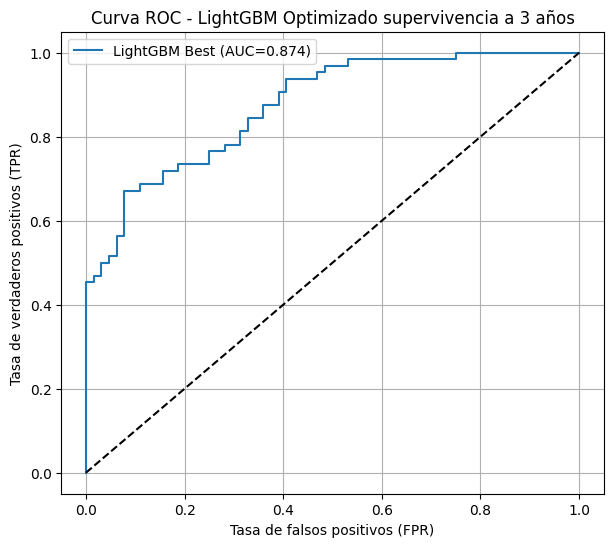

In [68]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_clf = LGBMClassifier(random_state=42)

grid_search = GridSearchCV(estimator=lgbm_clf, param_grid=param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
grid_search.fit(X, y)

best_lgbm = grid_search.best_estimator_

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"Mejor AUC ROC en validación cruzada: {grid_search.best_score_:.4f}")

# Evaluar con mejores hiperparámetros
auc_lgbm_best, y_test_lgbm_best, y_proba_lgbm_best = evaluar_modelo(best_lgbm, X, y, cv)
print(f"AUC ROC promedio LightGBM (grid search): {np.mean(auc_lgbm_best):.4f} ± {np.std(auc_lgbm_best):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_lgbm_best, y_proba_lgbm_best)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'LightGBM Best (AUC={auc_lgbm_best[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - LightGBM Optimizado supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

In [69]:
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

Mejores hiperparámetros encontrados:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores hiperparámetros: {'bootstrap': False, 'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
AUC ROC promedio Random Forest optimizado: 0.8717 ± 0.0150


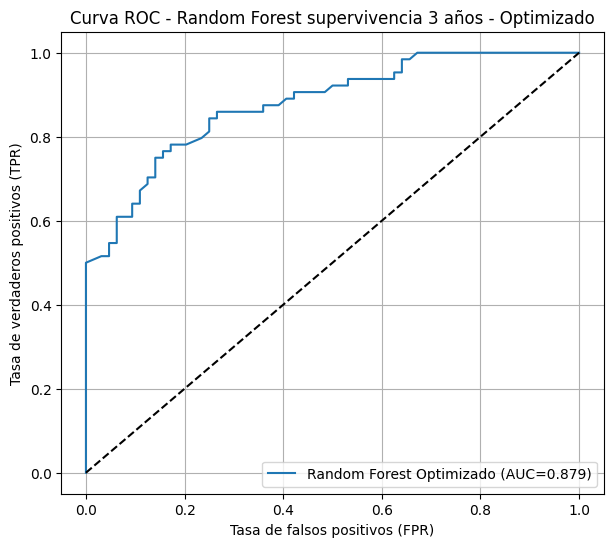

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define el modelo base
rf = RandomForestClassifier(random_state=42)

# Define la grilla de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.3, 0.5, 0.7],
    'bootstrap': [True, False]
}

# Definir validación cruzada estratificada 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Crear GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=2)

# Ajustar al conjunto de datos
grid_search.fit(X, y)

# Mejor conjunto de hiperparámetros encontrado
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo con la función evaluar_modelo que usas
best_rf = grid_search.best_estimator_
auc_scores, y_test, y_proba = evaluar_modelo(best_rf, X, y, cv)
print(f"AUC ROC promedio Random Forest optimizado: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# Graficar curva ROC del primer fold
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest Optimizado (AUC={auc_scores[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años - Optimizado')
plt.legend()
plt.grid(True)
plt.show()


Fitting 5 folds for each of 1728 candidates, totalling 8640 fits


d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:59:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores hiperparámetros XGBoost: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100, 'subsample': 0.8}


d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:59:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:59:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:59:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:59:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encode

AUC ROC promedio XGBoost optimizado: 0.8347 ± 0.0209


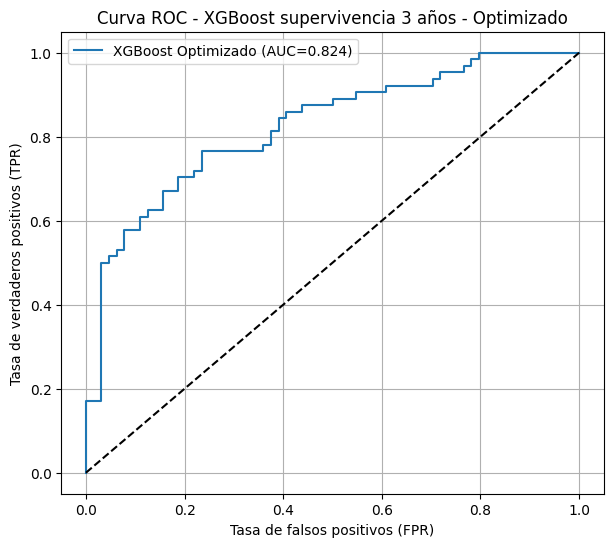

In [71]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define el modelo base
xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define la grilla de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

# Validación cruzada estratificada 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=2)

# Ajustar al conjunto de datos
grid_search_xgb.fit(X, y)

# Mejor conjunto de hiperparámetros encontrado
print("Mejores hiperparámetros XGBoost:", grid_search_xgb.best_params_)

# Evaluar el mejor modelo con tu función evaluar_modelo
best_xgb = grid_search_xgb.best_estimator_
auc_xgb, y_test_xgb, y_proba_xgb = evaluar_modelo(best_xgb, X, y, cv)
print(f"AUC ROC promedio XGBoost optimizado: {np.mean(auc_xgb):.4f} ± {np.std(auc_xgb):.4f}")

# Graficar curva ROC del primer fold
fpr, tpr, _ = roc_curve(y_test_xgb, y_proba_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'XGBoost Optimizado (AUC={auc_xgb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia 3 años - Optimizado')
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits


d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
4860 fits failed out of a total of 14580.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2500 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "

Mejores hiperparámetros Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 1.0}
AUC ROC promedio Gradient Boosting optimizado: 0.8735 ± 0.0220


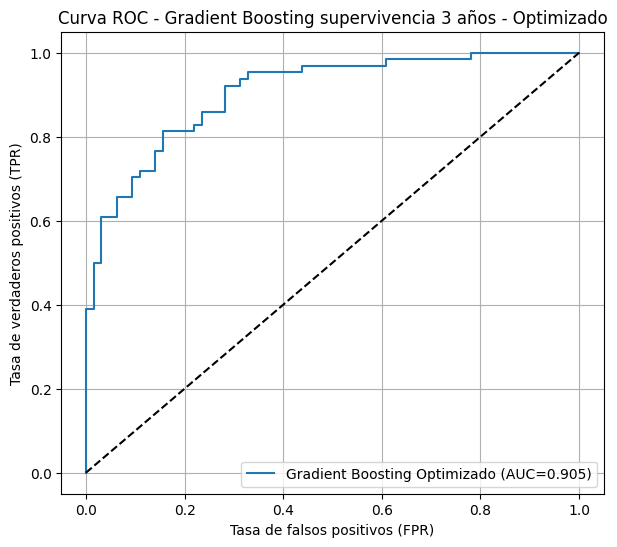

In [72]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Definir el modelo base sin ajustar parámetros
gb_clf = GradientBoostingClassifier(random_state=42)

# Definir rango de hiperparámetros a explorar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['auto', 'sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Validacion cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Crear GridSearchCV
grid_search = GridSearchCV(estimator=gb_clf, param_grid=param_grid,
                           scoring='roc_auc', cv=cv, n_jobs=-1, verbose=2)

# Ajustar al conjunto de datos
grid_search.fit(X, y)

# Mostrar mejores hiperparámetros
print("Mejores hiperparámetros Gradient Boosting:", grid_search.best_params_)

# Usar el mejor modelo para evaluar con tu función personalizada
best_gb = grid_search.best_estimator_
auc_gb, y_test_gb, y_proba_gb = evaluar_modelo(best_gb, X, y, cv)
print(f"AUC ROC promedio Gradient Boosting optimizado: {np.mean(auc_gb):.4f} ± {np.std(auc_gb):.4f}")

# Graficar la curva ROC del último fold
fpr, tpr, _ = roc_curve(y_test_gb, y_proba_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Gradient Boosting Optimizado (AUC={auc_gb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia 3 años - Optimizado')
plt.legend()
plt.grid(True)
plt.show()
